# Data Preprocessing and Feature Engineering

## Customer Churn Predictor
This notebook transforms the raw Telco Dataset into a model-ready dataset saved to `data/processed/`.

### 📋 Steps in This Notebook
1. Load raw data
2. Handle missing values and fix data types
3. Outlier detection
4. Encode categorical variables
5. Feature engineering
6. Scale numerical features
7. Save processed data

## Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import os
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style = 'whitegrid')

print('✅ Libraries imported successfully')

✅ Libraries imported successfully


## 1. Load Raw Data
We always load from `data/raw/` in the preprocessing notebook. The raw file should **never be modifie** as it is our source of truth that allows us to return this nnotebook from scratch at any time.

In [2]:
df = pd.read_csv('/Users/chldbng/Documents/projects/customer-churn-predictor/data/raw/telco-customer-churn.csv')

print(f'✅ Raw data loaded: {df.shape[0]} rows, {df.shape[1]} columns')
df.head()

✅ Raw data loaded: 7043 rows, 21 columns


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## 2. Handle Mssing Values and Fix Data Types

### Steps:
1. Drop `customerID` - it is a unique identifier with no predictive value. Including it would cause the model to memorize customer IDs rather than learn generalize patterns.
2. Fix `TotalCharges` - stored as string due to 11 empty string entries representing new customers with 0 tenure. We convert to numeric and fill with 0 since no charges have been incurred yet.
3. Encode `Churn` - convert Yes/No to 1/0 for modeling.

In [3]:
df.drop(columns=['customerID'], inplace=True)

# Fix TotalCharges — convert empty strings to 0
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Encode target variable
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

print(f'✅ Cleaned. Shape: {df.shape}')
print(f'✅ Remaining NaNs: {df.isnull().sum().sum()}')

✅ Cleaned. Shape: (7043, 20)
✅ Remaining NaNs: 0


## 3. Outlier Detection

### What Are Outliers?
Outliers are data points that lie **abnormally far from the majority** of observations. They can arise from:
* Data entry errors (e.g. a tenure of 999 months)
* Genuine extreme cases (e.g. a very high-value customer)
* System errors in data collection

### Why Do Outliers Matter?
* **Logistic Regression** is sensitive to outliers because extreme values shift the decision boundary
* **Tree-based models** are more robust to outliers since they split on thresholds rather than distances.

### How We Detect Them - IQR Method
The Interquartile Range (IQR) method flags values beyond:
* **Upper bound:** Q3 + 1.5 x IQR
* **Lower bound:** Q1 - 1.5 x IQR

Values outside of these bounds are considered potential outliers.

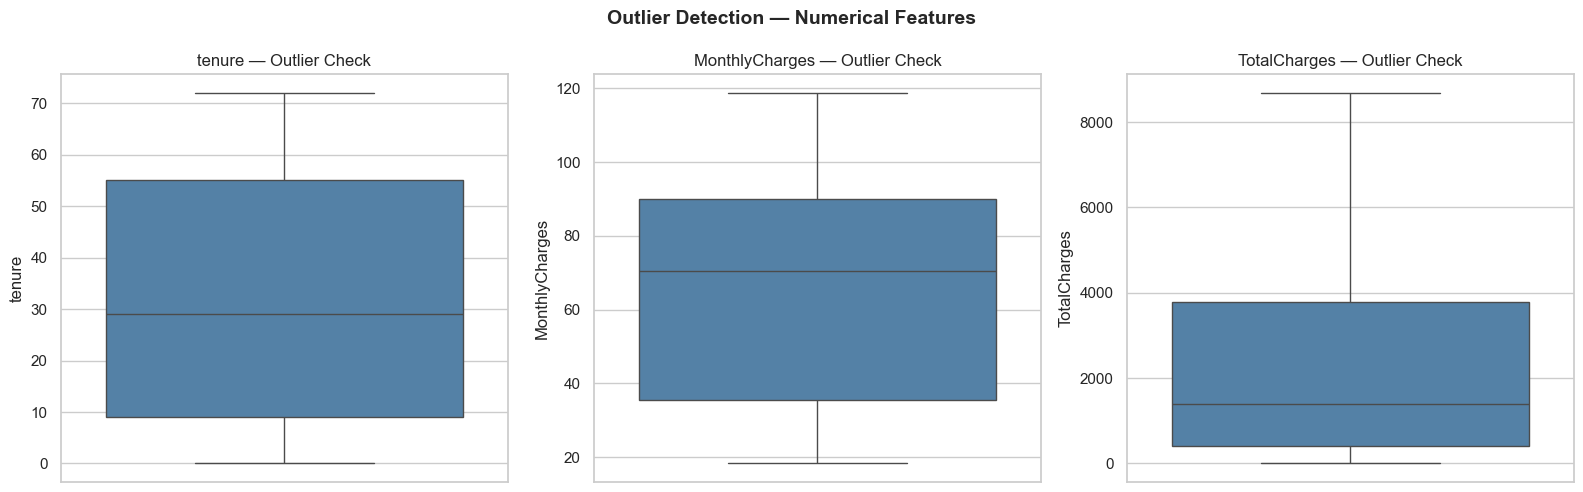

In [4]:
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

for i, col in enumerate(num_cols):
    sns.boxplot(data = df, y = col, ax = axes[i], color = 'steelblue')
    axes[i].set_title(f'{col} — Outlier Check')

plt.suptitle('Outlier Detection — Numerical Features', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/outlier_detection.png', dpi = 150, bbox_inches = 'tight')
plt.show()

In [5]:
print('=== IQR Outlier Analysis ===\n')

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f'{col}:')
    print(f'  Q1 = {Q1:.2f}, Q3 = {Q3:.2f}, IQR = {IQR:.2f}')
    print(f'  Lower bound = {lower:.2f}, Upper bound = {upper:.2f}')
    print(f'  Number of outliers: {len(outliers)}\n')

=== IQR Outlier Analysis ===

tenure:
  Q1 = 9.00, Q3 = 55.00, IQR = 46.00
  Lower bound = -60.00, Upper bound = 124.00
  Number of outliers: 0

MonthlyCharges:
  Q1 = 35.50, Q3 = 89.85, IQR = 54.35
  Lower bound = -46.02, Upper bound = 171.38
  Number of outliers: 0

TotalCharges:
  Q1 = 398.55, Q3 = 3786.60, IQR = 3388.05
  Lower bound = -4683.52, Upper bound = 8868.67
  Number of outliers: 0



## 4. Encode Categorical Variables

### Why Do We Encode?
Machine learning models are mathematical functions that operate on numbers. They can not process text strings like "Month-to-Month" or "Fiber optic" directly. Encoding converts these categories into numerical representations so the model can learn from them.

### Two Encoding Strategies We Use:
**Binary Encoding (Yes/No -> 1/0)**
For columns with exactly two values, we map directly to 1 and 0. This is memory efficient and preserves the binary nature of the feature.

**One-Hot Encoding**
For columns with 3+ categories, we create a new binary column per category. For example, `Contract` becomes:
* `Contract_One year` (1 if one-year, else 0)
* `Contract_Two year` (1 if two-year, else 0)
* Month-to-Month is the **reference category** (dropped via `drop_first = True`)

We use `drop_first = True` to avoid the **dummy variable trap**, which is a situation where one column is perfectly predictable from the others, causing multicollinearity that destabilizes Logistic Regression coefficients.

### Special Value Handling:
* `"No phone service"` in `MultipleLines` is replaced with `"No"`
* `"No internet service"` in service columns is replaced with `"No"`

These values carry the same meaning as "No" for modeling purposes, and consolidating them reduces unnecessary dimensionality.

In [6]:
binary_cols = ['Partner', 'Dependents', 'PhoneService', 'PaperlessBilling']
for col in binary_cols:
    df[col] = df[col].map({'Yes': 1, 'No': 0})

df['gender'] = df['gender'].map({'Male': 1, 'Female': 0})

service_cols = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
                'TechSupport', 'StreamingTV', 'StreamingMovies']
for col in service_cols:
    df[col] = df[col].replace({'No internet service': 'No'})

df['MultipleLines'] = df['MultipleLines'].replace({'No phone service': 'No'})

multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod', 'MultipleLines']

df = pd.get_dummies(df, columns = multi_cols, drop_first = True)

print(f'✅ Encoding complete. Shape: {df.shape}')
print(f'✅ Remaining NaNs: {df.isnull().sum().sum()}')
df.head()

✅ Encoding complete. Shape: (7043, 24)
✅ Remaining NaNs: 0


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Churn,...,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,MultipleLines_Yes
0,0,0,1,0,1,0,1,29.85,29.85,0,...,False,False,False,False,False,False,False,True,False,False
1,1,0,0,0,34,1,0,56.95,1889.50,0,...,True,False,False,False,True,False,False,False,True,False
2,1,0,0,0,2,1,1,53.85,108.15,1,...,False,False,False,False,False,False,False,False,True,False
3,1,0,0,0,45,0,0,42.30,1840.75,0,...,True,True,False,False,True,False,False,False,False,False
4,0,0,0,0,2,1,1,70.70,151.65,1,...,False,False,False,False,False,False,False,True,False,False


## 5. Feature Engineering

### What is Feature Engineering?
Feature engineering is the process of using **domain knowledge to create new features** from existing ones. It is one of the most impactful steps in the machine learning pipeline as a well-engineered feature can improve model performance more than switching to a more complex algorithm.

### Why Engineer Features?
Raw features don't always capture the full story. For example:
* `tenure` and `MonthlyCharges` individually are informative
* But their **ratio** (charges per month relative to tenure) may reveal customers who are pay a lot relative to how long they have been with us, which is a potentially strong churn signal.

### Features We Create:
| Feature | Formula | Business Rationale |
|---------|---------|-------------------|
| `charges_per_tenure` | MonthlyCharges / (tenure + 1) | High charges early in tenure = churn risk |
| `tenure_group` | Bin tenure into groups | Captures non-linear loyalty effect |
| `is_new_customer` | tenure <= 12 | New customers churn at higher rates |
| `is_long_term` | tenure >= 48 | Long-term customers are most loyal |
| `total_services` | Sum of all active services | More services = higher switching cost |
| `avg_charge_per_service` | MonthlyCharges / (total_services + 1) | Value perception per service |
| `has_no_support` | No TechSupport AND No OnlineSecurity | Lack of support = churn risk |
| `high_value` | MonthlyCharges > 75th percentile | High-value customers need retention focus |

*This part has been assisted with the use of Claude AI*

In [7]:
df['charges_per_tenure'] = df['MonthlyCharges'] / (df['tenure'] + 1)

df['tenure_group'] = pd.cut(
    df['tenure'],
    bins = [0, 12, 24, 48, 72],
    labels = ['New (0-12)', 'Developing (13-24)', 'Established (25-48)', 'Loyal (49-72)'])
df['tenure_group'] = df['tenure_group'].astype(str)
df = pd.get_dummies(df, columns = ['tenure_group'], drop_first = True)

df['is_new_customer'] = (df['tenure'] <= 12).astype(int)
df['is_long_term_customer'] = (df['tenure'] >= 48).astype(int)

service_cols_encoded = ['PhoneService', 'MultipleLines_Yes',
                        'OnlineSecurity_Yes', 'OnlineBackup_Yes',
                        'DeviceProtection_Yes', 'TechSupport_Yes',
                        'StreamingTV_Yes', 'StreamingMovies_Yes']

existing_service_cols = [c for c in service_cols_encoded if c in df.columns]
df['total_services'] = df[existing_service_cols].sum(axis = 1)

df['avg_charge_per_service'] = df['MonthlyCharges'] / (df['total_services'] + 1)

no_tech = 'TechSupport_Yes' in df.columns and df['TechSupport_Yes'] == 0
no_security = 'OnlineSecurity_Yes' in df.columns

if 'TechSupport_Yes' in df.columns and 'OnlineSecurity_Yes' in df.columns:
    df['has_no_support'] = (
        (df['TechSupport_Yes'] == 0) & (df['OnlineSecurity_Yes'] == 0)
    ).astype(int)

high_value_threshold = df['MonthlyCharges'].quantile(0.75)
df['is_high_value'] = (df['MonthlyCharges'] > high_value_threshold).astype(int)

print(f'✅ Feature engineering complete. New shape: {df.shape}')
print(f'\nNew features created:')
new_features = ['charges_per_tenure', 'is_new_customer', 'is_long_term_customer',
                'total_services', 'avg_charge_per_service', 'has_no_support', 'is_high_value']
for f in new_features:
    if f in df.columns:
        print(f'  ✓ {f}')

✅ Feature engineering complete. New shape: (7043, 34)

New features created:
  ✓ charges_per_tenure
  ✓ is_new_customer
  ✓ is_long_term_customer
  ✓ total_services
  ✓ avg_charge_per_service
  ✓ has_no_support
  ✓ is_high_value


### Verify New Features

In [8]:
engineered = ['charges_per_tenure', 'is_new_customer', 'is_long_term_customer',
              'total_services', 'avg_charge_per_service', 'is_high_value', 'Churn']

existing = [c for c in engineered if c in df.columns]
df[existing].describe().round(3)

,charges_per_tenure,is_new_customer,is_long_term_customer,is_high_value,Churn
count,7043.000,7043.000,7043.000,7043.000,7043.000
mean,5.771,0.310,0.327,0.250,0.265
std,8.722,0.463,0.469,0.433,0.442
min,0.264,0.000,0.000,0.000,0.000
25%,1.250,0.000,0.000,0.000,0.000
50%,2.076,0.000,0.000,0.000,0.000
75%,5.946,1.000,1.000,0.000,1.000
max,80.850,1.000,1.000,1.000,1.000


### Visualize New Features vs Churn

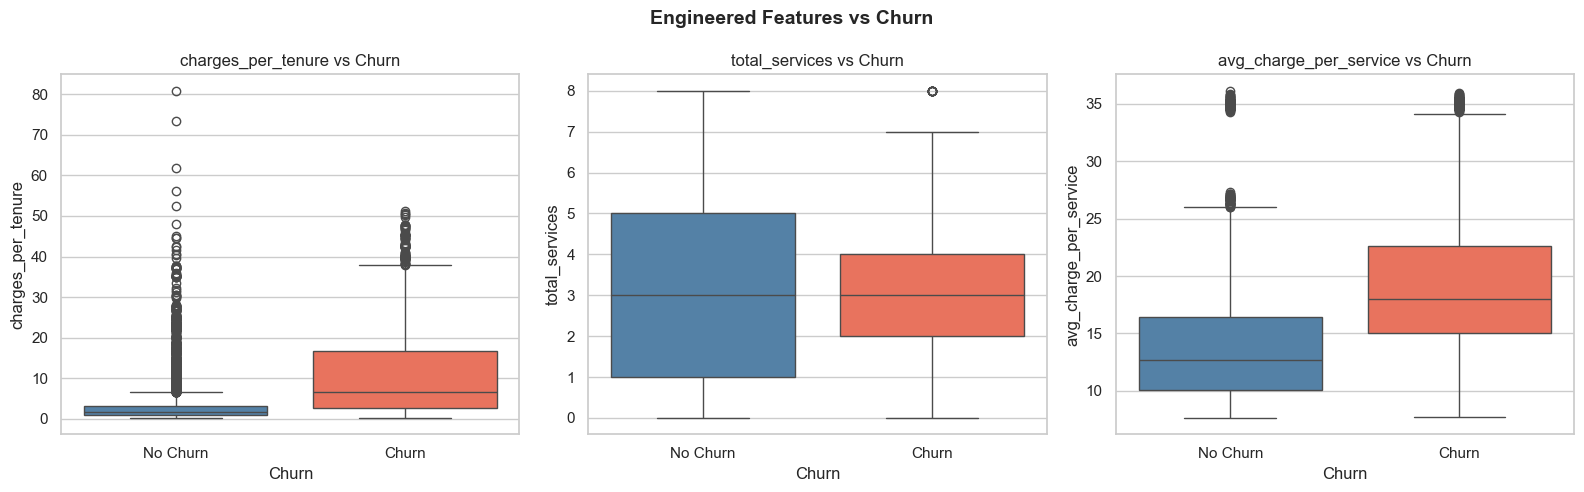

In [9]:
new_num_features = ['charges_per_tenure', 'total_services', 'avg_charge_per_service']

fig, axes = plt.subplots(1, 3, figsize = (16, 5))

for i, col in enumerate(new_num_features):
    sns.boxplot(data = df, x = 'Churn', y = col, ax = axes[i],
                palette = ['steelblue', 'tomato'])
    axes[i].set_title(f'{col} vs Churn')
    axes[i].set_xticklabels(['No Churn', 'Churn'])

plt.suptitle('Engineered Features vs Churn', fontsize = 14, fontweight = 'bold')
plt.tight_layout()
plt.savefig('../reports/figures/engineered_features.png', dpi = 150, bbox_inches = 'tight')
plt.show()

## 6. Scale Numerical Features

### Why Scale?
Feature scaling ensures all numerical features are on the **same scale** so that no single feature dominates due to its magnitude.

For example without scaling:
* `TotalCharges` ranges from 0 to ~8,000
* `SeniorCitizen` is only 0 to 1

Without scaling, Logistic Regression would treat `TotalCharges` as ~8,000x more important than `SeniorCitizen` simply because of its larger range.

### StandardScaler vs MinMaxScaler
| Scaler | Formula | Result | Best For |
|--------|---------|--------|----------|
| **StandardScaler** | (x - mean) / std | Mean=0, Std=1 | Logistic Regression, SVM |
| **MinMaxScaler** | (x - min) / (max - min) | Range 0 to 1 | Neural Networks |

We use **StandardScaler** for Logistic Regression.

### ⚠️ Important Rule:
We fit the scaler **only on training data** and transform both train and test sets. Fitting on the full dataset would cause **data leakage** — the model would have indirect knowledge of the test set during training, giving falsely optimistic results. This is handled automatically by our Sklearn Pipeline in the modeling notebook.

## 7. Save Processed Data
We save the fully cleaned and engineered dataset to `data/processed/` so that:
* The modeling notebook can load it directly without repeating preprocessing.
* Results are reproducible, and anyone can rerun the modeling notebook with the same processed data.
* Raw data remains untouched in `data/raw/`

In [10]:
os.makedirs('../data/processed/', exist_ok=True)

df.to_csv('../data/processed/telco_churn_processed.csv', index=False)

print('✅ Processed data saved to data/processed/telco_churn_processed.csv')
print(f'   Final shape: {df.shape}')
print(f'   Total features: {df.shape[1] - 1} (excluding target)')
print(f'   Total NaNs: {df.isnull().sum().sum()}')

✅ Processed data saved to data/processed/telco_churn_processed.csv
   Final shape: (7043, 34)
   Total features: 33 (excluding target)
   Total NaNs: 0


## Final Summary

In [11]:
print('=' * 50)
print('PREPROCESSING SUMMARY')
print('=' * 50)
print(f'Original shape: 7043 rows × 21 columns')
print(f'Processed shape: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Features created: {df.shape[1] - 21} new features engineered')
print(f'Missing values: {df.isnull().sum().sum()}')
print(f'Churn rate: {df["Churn"].mean():.2%}')
print(f'\nSaved to: data/processed/telco_churn_processed.csv')

PREPROCESSING SUMMARY
Original shape: 7043 rows × 21 columns
Processed shape: 7043 rows × 34 columns
Features created: 13 new features engineered
Missing values: 0
Churn rate: 26.54%

Saved to: data/processed/telco_churn_processed.csv
